In [14]:
import pandas as pd
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Commect to MYSQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Caballo#24",
    database="thesis_berlin"
)

# Load the data from the tables
query_respondents = "SELECT * FROM respondents"
query_spending = "SELECT * FROM spending"
query_transport = """
    SELECT r.respondent_id, tm.method_name, tc.travel_time, tc.travel_district
    FROM respondents r
    JOIN transport_choices tc ON r.respondent_id = tc.respondent_id
    JOIN transport_methods tm ON tc.method_id = tm.method_id
"""
query_events = """
    SELECT r.respondent_id, em.event_name
    FROM respondents r
    JOIN respondent_events re ON r.respondent_id = re.respondent_id
    JOIN event_types_master em ON re.event_id = em.event_id
"""

df_respondents = pd.read_sql(query_respondents, conn)
df_spending = pd.read_sql(query_spending, conn)
df_transport = pd.read_sql(query_transport, conn)
df_events = pd.read_sql(query_events, conn)

# Close the connection
conn.close()

# Verify the data was loaded correctly
print("✅ Data loaded successfully:")
print(f"Respondents: {len(df_respondents)} rows")
print(f"Spending: {len(df_spending)} rows")
print(f"Transport: {len(df_transport)} rows")
print(f"Events: {len(df_events)} rows")

✅ Data loaded successfully:
Respondents: 55 rows
Spending: 55 rows
Transport: 53 rows
Events: 122 rows


C:\Users\jogea\AppData\Local\Temp\ipykernel_29776\925833212.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_respondents = pd.read_sql(query_respondents, conn)
C:\Users\jogea\AppData\Local\Temp\ipykernel_29776\925833212.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_spending = pd.read_sql(query_spending, conn)
C:\Users\jogea\AppData\Local\Temp\ipykernel_29776\925833212.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_transport = pd.read_sql(query_transport, conn)
C:\Users\jogea\AppData\Local\Temp\ipyk

In [16]:
# Show first few rows of each table
print("\n🔍 First rows of Respondents:")
print(df_respondents.head())


🔍 First rows of Respondents:
   respondent_id           timestamp    age  gender nationality  \
0              1 2026-08-14 13:40:29  26-35    Male      Mexico   
1              2 2026-08-14 14:00:52  18-25    Male       India   
2              3 2026-08-14 14:01:08  26-35    Male       Chile   
3              4 2026-08-14 14:09:24  36-45    Male     Ecuador   
4              5 2026-08-14 14:19:35  18-25  Female      Panama   

                   education                    district attended  \
0  Master's degree or higher                       Other      Yes   
1          Bachelor's degree                    Neukölln      Yes   
2          Bachelor's degree                      Pankow      Yes   
3  Master's degree or higher            Treptow-Köpenick      Yes   
4        Secondary education  Charlottenburg-Wilmersdorf      Yes   

      frequency  satisfaction  \
0          6-10           5.0   
1           3-5           4.0   
2          6-10           5.0   
3           3-5     

In [18]:
print("\n🔍 First rows of Spending:")
print(df_spending.head())


🔍 First rows of Spending:
   spending_id  respondent_id  ticket  food_inside  food_outside  \
0            1              1   113.0         14.0           0.0   
1            2              2    10.0         15.0          10.0   
2            3              3     0.0         25.0          30.0   
3            4              4    10.0         10.0           0.0   
4            5              5    10.0         10.0           7.0   

   other_expenses  total_spend  
0            49.0        176.0  
1            15.0         50.0  
2             0.0         60.0  
3             0.0         10.0  
4             0.0         30.0  


In [20]:
print("\n🔍 First rows of Transport:")
print(df_transport.head())


🔍 First rows of Transport:
   respondent_id                                   method_name  \
0              1  Public transport (U-Bahn, S-Bahn, bus, tram)   
1              2  Public transport (U-Bahn, S-Bahn, bus, tram)   
2              3  Public transport (U-Bahn, S-Bahn, bus, tram)   
3              4  Public transport (U-Bahn, S-Bahn, bus, tram)   
4              5  Public transport (U-Bahn, S-Bahn, bus, tram)   

            travel_time             travel_district  
0  More than 60 minutes                       Other  
1         15-30 minutes                    Neukölln  
2         30-60 minutes                      Pankow  
3         30-60 minutes            Treptow-Köpenick  
4         30-60 minutes  Charlottenburg-Wilmersdorf  


In [21]:
print("\n🔍 First rows of Events:")
print(df_events.head())


🔍 First rows of Events:
   respondent_id               event_name
0              2  Art exhibition / Museum
1              3  Art exhibition / Museum
2              7  Art exhibition / Museum
3              8  Art exhibition / Museum
4              9  Art exhibition / Museum


## Exploratory Data Analysis

In [22]:
# --- MERGE SPENDING DATA WITH RESPONDENTS ---
df = df_respondents.merge(df_spending, on='respondent_id')

# --- 1. DESCRIPTIVE STATISTICS ---
print("\n📊 Descriptive Statistics for Spending:")
print(df['total_spend'].describe())


📊 Descriptive Statistics for Spending:
count     53.000000
mean      72.377358
std       78.414389
min        5.000000
25%       34.000000
50%       50.000000
75%       80.000000
max      500.000000
Name: total_spend, dtype: float64


In [23]:
# --- 2. SPENDING BY AGE GROUP ---
print("\n📊 Average Spending by Age Group:")
print(df.groupby('age')['total_spend'].mean().sort_values(ascending=False))


📊 Average Spending by Age Group:
age
18-25    76.307692
26-35    75.172414
36-45    64.250000
46-55    50.000000
Name: total_spend, dtype: float64


In [24]:
# --- 3. SPENDING BY NATIONALITY ---
print("\n📊 Top 5 Nationalities by Average Spending:")
print(df.groupby('nationality')['total_spend'].mean().sort_values(ascending=False).head(5))


📊 Top 5 Nationalities by Average Spending:
nationality
Sweden     300.0
Brazil     150.0
India      116.5
Germany     92.0
Ghana       80.0
Name: total_spend, dtype: float64


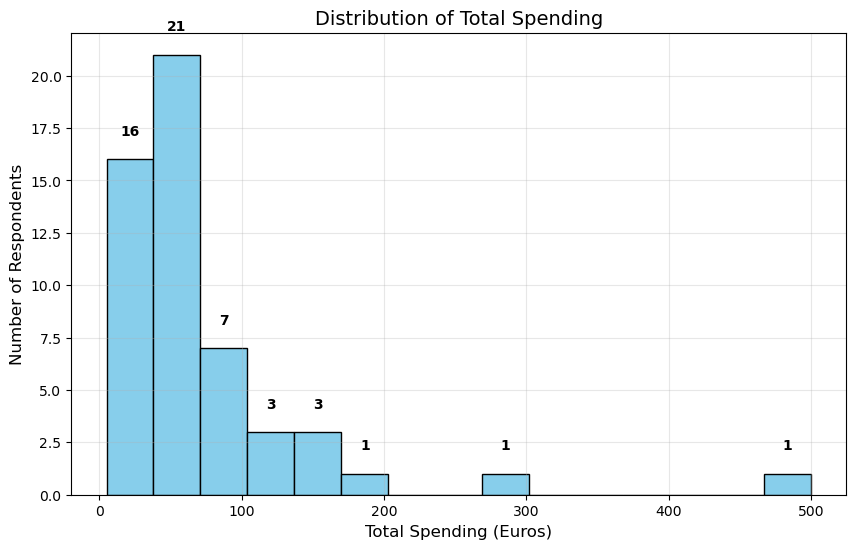

In [28]:
# --- 4. SPENDING DISTRIBUTION HISTOGRAM ---
plt.figure(figsize=(10,6))
counts, bins, patches = plt.hist(df['total_spend'], bins=15, color='skyblue', edgecolor='black')

for count, bin_edge in zip(counts, bins[:-1]):
    if count > 0:
        plt.text(bin_edge + (bins[1] - bins[0]) / 2, count + 1, str(int(count)), 
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.title('Distribution of Total Spending', fontsize=14)
plt.xlabel('Total Spending (Euros)', fontsize=12)
plt.ylabel('Number of Respondents', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

## Statistical Tests

In [49]:
# --- 1. CHI-SQUARE TEST: Event Type vs. Transport Mode ---
# Create a contingency table
contingency = pd.crosstab(df_events['event_name'], df_transport['method_name'])
print("\n🔍 Contingency Table - Event Type vs Transport Mode:")
print(contingency)

# Perform Chi-square test
chi2, p, dof, expected = stats.chi2_contingency(contingency)
print(f"\n📊 Chi-square Test Results:")
print(f"Chi-square: {chi2:.4f}")
print(f"p-value: {p:.4f}")
if p < 0.05:
    print("✅ The relationship is statistically significant (p < 0.05)")
else:
    print("❌ No significant relationship found (p >= 0.05)")


🔍 Contingency Table - Event Type vs Transport Mode:
method_name                                         Bicycle  \
event_name                                                    
Art exhibition / Museum                                   2   
Cultural fair / Market                                    2   
Music concert (rock, pop, electronic, classical...        1   

method_name                                         Public transport (U-Bahn, S-Bahn, bus, tram)  \
event_name                                                                                         
Art exhibition / Museum                                                                       20   
Cultural fair / Market                                                                        22   
Music concert (rock, pop, electronic, classical...                                             3   

method_name                                         Taxi / Uber / Cabify  
event_name                                             

In [48]:
# --- 2. MANN-WHITNEY U TEST: Spending by Gender ---
male_spending = df[df['gender'] == 'Male']['total_spend']
female_spending = df[df['gender'] == 'Female']['total_spend']

stat, p_value = stats.mannwhitneyu(male_spending, female_spending)
print(f"\n📊 Mann-Whitney U Test - Spending by Gender:")
print(f"Statistic: {stat:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("✅ Significant difference in spending between genders")
else:
    print("❌ No significant difference in spending between genders")


📊 Mann-Whitney U Test - Spending by Gender:
Statistic: nan
p-value: nan
❌ No significant difference in spending between genders


## K-Means Clustering

C:\Users\jogea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jogea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jogea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\jogea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

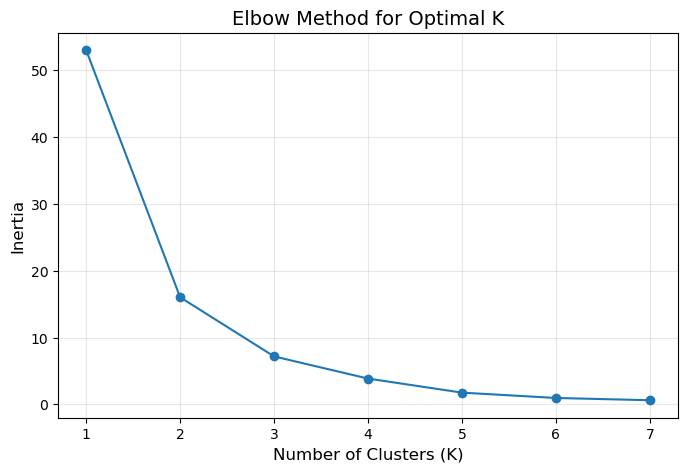

In [51]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# --- CLEAN DATA: Remove rows with NaN in total_spend ---
df_clean = df[df['total_spend'].notna()].copy()

# --- PREPARE DATA FOR CLUSTERING ---
X = df_clean[['total_spend']].copy()

# --- SCALE THE DATA ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- ELBOW METHOD TO FIND OPTIMAL NUMBER OF CLUSTERS ---
inertias = []
for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# --- PLOT THE ELBOW CURVE ---
plt.figure(figsize=(8,5))
plt.plot(range(1, 8), inertias, marker='o')
plt.title('Elbow Method for Optimal K', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

In [53]:
# --- APPLY K-MEANS WITH K=3 (example) ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clean['segment'] = kmeans.fit_predict(X_scaled)

# --- VIEW SEGMENT STATISTICS ---
print("\n📊 Segment Statistics:")
print(df_clean.groupby('segment')['total_spend'].agg(['count', 'mean', 'min', 'max']))


📊 Segment Statistics:
         count        mean    min    max
segment                                 
0           38   40.605263    5.0   75.0
1            2  400.000000  300.0  500.0
2           13  114.846154   80.0  176.0


C:\Users\jogea\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


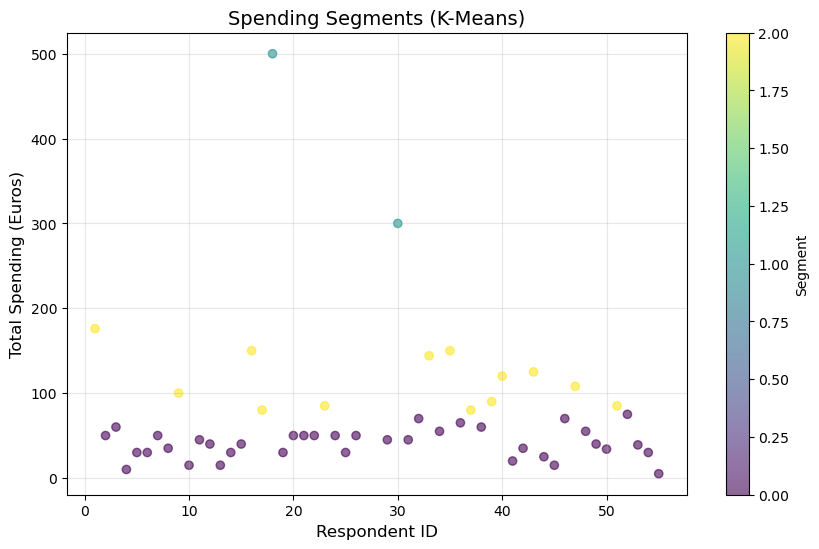

In [54]:
# --- VISUALIZE THE SEGMENTS ---
plt.figure(figsize=(10,6))
plt.scatter(df_clean['respondent_id'], df_clean['total_spend'], c=df_clean['segment'], cmap='viridis', alpha=0.6)
plt.title('Spending Segments (K-Means)', fontsize=14)
plt.xlabel('Respondent ID', fontsize=12)
plt.ylabel('Total Spending (Euros)', fontsize=12)
plt.colorbar(label='Segment')
plt.grid(alpha=0.3)
plt.show()

# Stripe - Simulated Data

📊 Summary of simulated payments:
Total transactions with event name: 127
Total revenue: €3365.00
Average transaction: €26.50

📊 Spending by Event Type:
Description
Theatre Play        980
Music Festival      945
Berlin Concert      825
Night Club Event    375
Art Exhibition      240
Name: Amount, dtype: int64


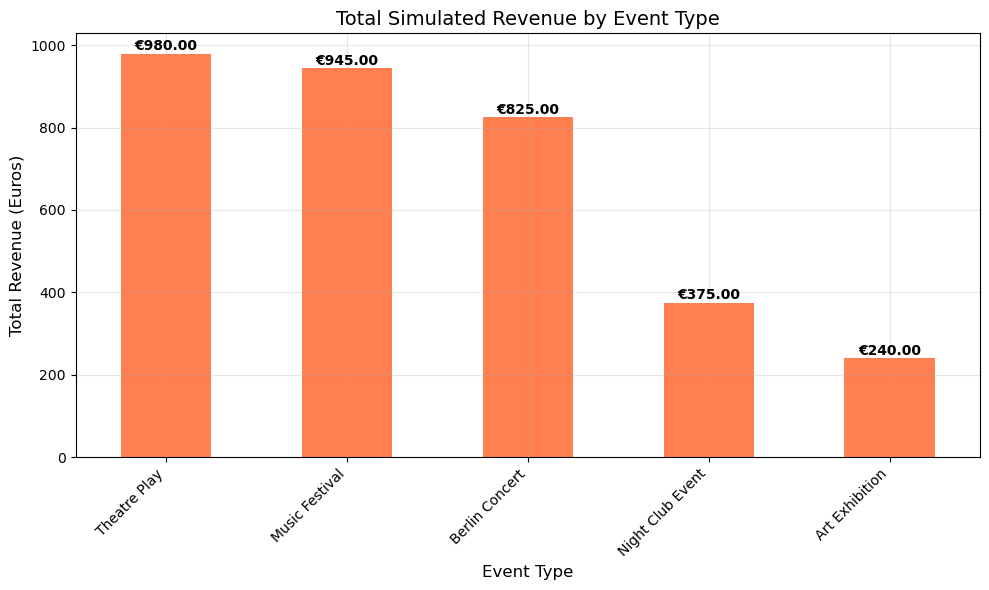

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

# --- READ THE STRIPE CSV ---
df_stripe = pd.read_csv("C:/Users/jogea/Downloads/unified_payments (1)(in).csv")

# --- FILTER ONLY ROWS WITH A DESCRIPTION (EVENT NAME) ---
df_clean = df_stripe[df_stripe['Description'].notna()]

# --- BASIC STATISTICS (NO DIVISION) ---
print("📊 Summary of simulated payments:")
print(f"Total transactions with event name: {len(df_clean)}")
print(f"Total revenue: €{df_clean['Amount'].sum():.2f}")
print(f"Average transaction: €{df_clean['Amount'].mean():.2f}")

# --- GROUP BY EVENT TYPE (NO DIVISION) ---
spending_by_event = df_clean.groupby('Description')['Amount'].sum()
spending_by_event = spending_by_event.sort_values(ascending=False)

print("\n📊 Spending by Event Type:")
print(spending_by_event)

# --- CHART (NO DIVISION) ---
plt.figure(figsize=(10,6))
ax = spending_by_event.plot(kind='bar', color='coral')
plt.title('Total Simulated Revenue by Event Type', fontsize=14)
plt.xlabel('Event Type', fontsize=12)
plt.ylabel('Total Revenue (Euros)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(alpha=0.3)

for i, v in enumerate(spending_by_event):
    ax.text(i, v + 1, f'€{v:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()